<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/lg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install uv
!uv pip install langchain-mistralai
!uv pip install langchain-tavily
!uv pip install langchain-community[all]
!uv pip install Wikipedia
!uv pip install langchain-community
!uv pip install wikipedia langchain-community


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 30.3 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 46 packages in 768ms
Prepared 2 packages in 18ms
Installed 2 packages in 2ms
 + httpx-sse==0.4.3
 + langchain-mistralai==1.1.6
Using Python 3.12.13 environment at: /usr
Resolved 45 packages in 1.01s
Prepared 1 package in 20ms
Installed 1 package in 1ms
 + langchain-tavily==0.2.18
Using Python 3.12.13 environment at: /usr
Resolved 47 packages in 359ms
Prepared 5 packages in 327ms
Uninstalled 1 package in 2ms
Installed 5 packages in 59ms
 + langchain-classic==1.0.8
 + langchain-community==0.4.2
 + langchain-text-splitters==1.1.2
 + pydantic-settings==2.14.2
 - requests==2.32.4
 + requests==2.34.2
Using Python 3.12.13 environment at: /usr
Resolved 9 packages in 1.32s
Prepared 1 package in 428ms
Installed 1 package in 1ms
 + wikipedia==1.4.0
Using Python 3.12.13 environment at: /usr
Checked 1 package in 145ms
Using Python 3.12.13 environment at: /usr
Checked 2 p

In [2]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from rich import print
from pprint import pprint
from langchain.tools import tool
from typing import TypedDict
from operator import add
from typing import Annotated , List
from pydantic import BaseModel , Field

In [3]:
CHAT_MISTRAL_API_KEY = ""

In [4]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY,
    temperature = 0
)
print(llm.invoke("hello"))

AIMessage(
    content='Hello! 😊 How can I assist you today?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 4,
            'total_tokens': 17,
            'completion_tokens': 13,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f615b-d971-7fb3-905a-1066d41d2c27-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 4, 'output_tokens': 13, 'total_tokens': 17}
)

In [5]:
from langchain_tavily import TavilySearch
import os
os.environ["TAVILY_API_KEY"] = ""
tavily = TavilySearch(max_results=3)

res = tavily.invoke({"query": "who is ronaldo"})
print(res)

{
    'query': 'who is ronaldo',
    'follow_up_questions': None,
    'answer': None,
    'images': [],
    'results': [
        {
            'url': 'https://en.wikipedia.org/wiki/Ronaldo_(Brazilian_footballer)',
            'title': 'Ronaldo (Brazilian footballer) - Wikipedia',
            'content': '# Ronaldo (Brazilian footballer). He joined Barcelona in 1996 for a then world record 
transfer fee and at 20 years old, he was named the 1996 FIFA World Player of the Year, making him the youngest 
recipient of the award. At age 17, he was the youngest member of the Brazilian squad that won the 1994 FIFA World 
Cup. At the 1998 FIFA World Cup, Ronaldo received the Golden Ball "Golden Ball (FIFA)") as the player of the 
tournament after he helped Brazil reach the final, where he suffered a convulsive fit hours before kick-off. This 
achievement, viewed as "redemption" for what occurred at the previous World Cup, saw Ronaldo named the 2002 FIFA 
World Player of the Year, receive the 2002 Ballon d\'Or, and for his return from injury, won the Laureus World 
Sports Award for Comeback of the Year. At the 2006 FIFA World Cup, Ronaldo scored his 15th World Cup goal, a 
tournament record at the time.',
            'score': 0.78866494,
            'raw_content': None
        },
        {
            'url': 'https://www.britannica.com/biography/Cristiano-Ronaldo',
            'title': 'Cristiano Ronaldo | 2026 FIFA World Cup, Goals, Portugal, Biography, Football, & Facts | 
Britannica',
            'content': '# Cristiano Ronaldo. Cristiano Ronaldo was born on February 5, 1985, in Funchal, Madeira, 
Portugal. Ronaldo joined Clube Desportivo Nacional of Madeira and then transferred to Sporting Clube de Portugal 
(known as Sporting Lisbon), where he played for that club’s various youth football (soccer) teams before making his
debut on Sporting’s first team in 2002. He is the all-time leading scorer for Spain’s Real Madrid. Ronaldo helped 
United to a Champions League title in May 2008 and captured Fédération Internationale de Football Association 
(FIFA) World Player of the Year honours for his stellar 2007–08 season. He was captain of Portugal’s national team 
in the 2014 and 2018 World Cup competitions and was the third person to earn a lifetime contract from the 
sportswear company Nike. Ronaldo is the winner of five Ballon d’Or awards (2008, 2013, 2014, 2016, and 2017), and 
in 2024 he became the first men’s player to score 900 career goals in official matches.',
            'score': 0.7336813,
            'raw_content': None
        },
        {
            'url': 
'https://www.realmadrid.com/en-US/the-club/history/football-legends/cristiano-ronaldo-dos-santos-aveiro',
            'title': 'Cristiano Ronaldo Dos Santos Aveiro - History and honours | Official website Real Madrid 
C.F.',
            'content': "# Cristiano Ronaldo. Cristiano Ronaldo is a part of Real Madrid's legacy and will forever 
be remember as one of the great icons throughout the club's history. During the course of his nine seasons as a 
Real Madrid player, Ronaldo secured a number of impressive records: the club's all-time leading goalscorer, the 
leading marksmen in European Cup history (he scored 105 goals for Real Madrid in the Champions League); the 
all-time leading madridista goalscorer in LaLiga (312); highest number of games in which a player has scored three 
or more times in LaLiga history (34); and the most goals to have been scored by a Real Madrid player in a single 
season (61).",
            'score': 0.7180613,
            'raw_content': None
        }
    ],
    'response_time': 0.0,
    'request_id': 'a2bb3697-2673-4d6c-95c9-22f4a89b3c17'
}

In [6]:
from langchain_community.document_loaders import WikipediaLoader
import wikipedia

wikipedia.set_user_agent("MyLangChainAgent/1.0 (unknownlegendff7@gmail.com)")
search_docs = WikipediaLoader(query="who is ronaldo", load_max_docs=2).load()
print(search_docs)

/tmp/ipykernel_1425/385149523.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


[
    Document(
        metadata={
            'title': 'Cristiano Ronaldo',
            'summary': "Cristiano Ronaldo dos Santos Aveiro (born 5 February 1985) is a Portuguese professional 
footballer who plays as a forward for and captains the Saudi Pro League club Al-Nassr and the Portugal national 
team. Widely regarded as one of the greatest players in history and the greatest Portuguese player ever, he has won
numerous individual accolades throughout his career, including five Ballon d'Or awards, a record three UEFA Men's 
Player of the Year Awards, and four European Golden Shoes. He was named the world's best player five times by 
FIFA.\nNicknamed CR7, Ronaldo is one of the most decorated players in the history of professional football, having 
won 35 trophies in his career, including five UEFA Champions Leagues, two UEFA Nations Leagues and the UEFA 
European Championship. He holds the records for most goals (140) and assists (42) in the Champions League, most 
goals (14) and assists (8) in the European Championship, most international appearances (233), most men's 
international goals (146) and most international victories (141). He is the only player to have scored 100 goals 
with four different clubs and to finish as top scorer in four different domestic leagues. He has made over 1,300 
professional career appearances, the most by an outfield player, and has scored over 970 official senior career 
goals for club and country, making him the top goalscorer of all time.\nBorn in Funchal, Madeira, Ronaldo began his
career with Sporting CP before signing with Manchester United in 2003. He gradually established himself as an 
integral player for the club, winning three consecutive Premier League titles, the 2007–08 Champions League, and 
the 2008 FIFA Club World Cup. For his performances in 2007–08, Ronaldo was awarded his first Ballon d'Or at age 23.
In 2009, he joined Real Madrid in a deal worth €94 million (£80 million), which was the most expensive transfer in 
history at the time. He was at the forefront of Madrid's resurgence as a dominant European force, helping them win 
four Champions Leagues between 2014 and 2018, including the long-awaited La Décima in 2014, where he set the record
for most goals scored in a Champions League season. With Madrid, he also won two La Liga titles, won the Ballon 
d'Or in 2013, 2014, 2016 and 2017, and became the club's all-time top goalscorer.\nFollowing issues with the 
hierarchy at Real Madrid, Ronaldo signed for Juventus in 2018 in a transfer worth a league record of €100 million, 
and was pivotal in winning two consecutive Serie A titles, the Coppa Italia, and the Capocannoniere in 2021 as the 
league's top scorer. In 2021, he returned to Manchester United, but his contract was terminated in 2022 after a 
public dispute with the club's management. Ronaldo joined Al-Nassr in 2023, and led them to the Saudi Pro League 
title in 2026, while also finishing as the league's top scorer in 2024 and 2025.\nRonaldo made his international 
debut for Portugal in 2003 at the age of 18, and has earned more than 200 caps, making him history's most-capped 
male player. He scored his first international goal in Euro 2004, where he helped Portugal reach the final. He 
assumed the captaincy of the national team ahead of Euro 2008, and led Portugal to their first major tournament 
title at Euro 2016. At Euro 2020, he received the Golden Boot as the top scorer. He won the UEFA Nations Leagues in
2019 and 2025, finishing as the top scorer in both the tournaments. In 2026, he became the first player to score in
six World Cup tournaments.\n\nOne of the world's most famous and marketable athletes, Ronaldo was ranked by 
Sportico as the third highest-paid athlete of all time in April 2026. In 2026, Ronaldo appeared on the Forbes 
World’s Billionaires list for the first time, with a net worth of $1.2B. Time included him on their list of the 100
most influential people in the world in 2014. He is the most 

In [7]:
analyst_instructions="""You are tasked with creating a set of AI analyst
personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts:

{human_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [8]:
class Analyst(BaseModel):
  name : str = Field(description = "Name of the Analyst")
  affiliation : str = Field(description = "primary affiliation of the analyst")
  role : str = Field(description = "Role of the analyst in the context of the topic")
  description : str = Field(description = "Description of the analyst focus, concerns, and motives")

  @property
  def persona(self)->str:
    return f"Name : {self.name}\nRole {self.role}\nAffiliation : {self.affiliation}\n Description : {self.description}\n"

class Perspective(BaseModel):
  analyst : List[Analyst]= Field(description = "Comprehensive list of analysts with their roles and affiliations")

In [9]:
class OverallState(TypedDict):
  topic : str
  max_analyst : int
  human_analyst_feedback : str
  analysts : List[Analyst]

In [10]:
def analyst_creator(state : OverallState):
  max_analyst = state['max_analyst']
  topic = state['topic']
  human_feedback = state.get('human_feedback', '')
  prompt = analyst_instructions.format(topic = topic , human_feedback = human_feedback , max_analysts = max_analyst)

  structured_llm = llm.with_structured_output(Perspective)

  analyst = structured_llm.invoke([
      SystemMessage(content=prompt)
  ] + [HumanMessage(content='generate set of analysts')])

  return {'analysts':analyst.analyst}


In [11]:
def human_feedback_node(state : OverallState):
  return state

In [12]:
def should_continue(state : OverallState):
  human_feedback=state.get('human_analyst_feedback', None)
  if human_feedback:
    return "analyst_creator"
  else:
    return END

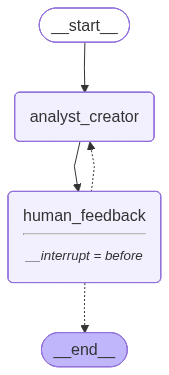

In [13]:
builder = StateGraph(OverallState)
builder.add_node("analyst_creator",analyst_creator)
builder.add_node("human_feedback",human_feedback_node)

builder.add_edge(START , "analyst_creator")
builder.add_edge("analyst_creator" , "human_feedback")
builder.add_conditional_edges("human_feedback",should_continue , ['analyst_creator',END])

memory = MemorySaver()

graph = builder.compile(memory , interrupt_before = ['human_feedback'])

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [14]:
max_assistant = 3
topic = "why we require notebooks if we have laptops and tablets"
config = {'configurable':{'thread_id':1}}

for event in graph.stream({"topic":topic,"max_analyst":max_assistant},config ,
                          stream_mode="values"):
  print(event)

{'topic': 'why we require notebooks if we have laptops and tablets', 'max_analyst': 3}

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'analysts': [
        Analyst(
            name='Dr. Elizabeth Hartwell',
            affiliation='Institute for Technology and Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of technology. She is concerned with 
how different devices affect learning outcomes and student engagement. Her motive is to optimize educational 
experiences through the appropriate use of technology.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='TechInsight Analytics',
            role='Market Analyst',
            description='Marcus Chen analyzes market trends and consumer behavior in the tech industry. He is 
interested in understanding why consumers choose certain devices for specific tasks and how this affects market 
dynamics. His goal is to provide insights that can guide product development and marketing strategies.'
        ),
        Analyst(
            name='Sophia Ramirez',
            affiliation='Ergonomics and Design Research Group',
            role='Ergonomics Specialist',
            description='Sophia Ramirez studies the ergonomic aspects of various devices. She is particularly 
interested in how the form and function of notebooks, laptops, and tablets impact user comfort and productivity. 
Her aim is to advocate for designs that enhance user well-being and efficiency.'
        )
    ]
}

In [15]:
graph.get_state(config).next

('human_feedback',)

In [16]:
human_feedback = "Could you add more analyst from different fields also"
for event in graph.stream({"human_feedback":human_feedback},config ,
                          stream_mode="values"):
  print(event)

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'analysts': [
        Analyst(
            name='Dr. Elizabeth Hartwell',
            affiliation='Institute for Technology and Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of technology use. She is concerned 
with how different devices influence learning outcomes and student engagement. Her motive is to optimize 
educational experiences through the appropriate use of technology.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='Ergonomics and Design Research Group',
            role='Ergonomics Specialist',
            description='Marcus Chen examines the ergonomic aspects of using various devices. He is interested in 
how notebooks, laptops, and tablets affect user comfort and productivity. His goal is to provide recommendations 
based on ergonomic research to improve user well-being and efficiency.'
        ),
        Analyst(
            name='Sophia Ramirez',
            affiliation='Consumer Technology Review',
            role='Technology Critic',
            description='Sophia Ramirez reviews and critiques consumer technology. She is particularly interested 
in the practical uses and limitations of different devices. Her aim is to inform consumers about the best choices 
for their needs, balancing functionality, cost, and user experience.'
        )
    ]
}

In [17]:
graph.get_state(config).next

('human_feedback',)

In [18]:
further_feedback = None

In [19]:
graph.update_state(config,{"human_analyst_feedback":further_feedback},as_node = 'human_feedback')

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17f9d4-1622-6862-8005-cf3fc723bb57'}}

In [20]:
graph.get_state(config).next

()

In [21]:
for event in graph.stream(None,config ,
                          stream_mode="updates"):
  print(event)

In [22]:
print(graph.get_state(config).next)

()

In [23]:
for analyst in graph.get_state(config).values.get('analysts'):
  print(f"Name :        {analyst.name}")
  print(f"Role :        {analyst.role}")
  print(f"Affiliation : {analyst.affiliation}")
  print(f"Description : {analyst.description}")
  print('-'*50)

Name :        Dr. Elizabeth Hartwell

Role :        Educational Technologist

Affiliation : Institute for Technology and Learning

Description : Dr. Hartwell focuses on the educational implications of technology use. She is concerned with how 
different devices influence learning outcomes and student engagement. Her motive is to optimize educational 
experiences through the appropriate use of technology.

--------------------------------------------------

...

Name :        Sophia Ramirez

Role :        Technology Critic

Affiliation : Consumer Technology Review

Description : Sophia Ramirez reviews and critiques consumer technology. She is particularly interested in the 
practical uses and limitations of different devices. Her aim is to inform consumers about the best choices for 
their needs, balancing functionality, cost, and user experience.

--------------------------------------------------

In [24]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic.

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.

2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}

Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.

When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [25]:
import operator
class State(MessagesState):
  max_num_turns : int
  interview : str
  sections : list
  analyst : Analyst
  context : Annotated[List , operator.add]

class SearchQuery(BaseModel):
  search_query: str = Field(None, description="Search query for retrieval.")


In [26]:
def create_question(state : State):
  messages = state['messages']
  analyst = state['analyst']

  system_message = question_instructions.format(goals = analyst.persona)
  conversation = get_buffer_string(messages)

  questions = llm.invoke([SystemMessage(content = system_message),HumanMessage(content=conversation)])

  return {'messages':[questions]}

In [27]:
from langchain_core.messages import get_buffer_string

search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert.

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.

First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

In [28]:
def web_search(state : State):
  structure_llm = llm.with_structured_output(SearchQuery)
  conversation = get_buffer_string(state['messages'])
  search_query = structure_llm.invoke([search_instructions] + [HumanMessage(content=conversation)])


  data = tavily.invoke({'query':search_query.search_query})
  search_docs = data.get("results",data)

  formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

  return {"context": [formatted_search_docs]}

In [29]:
def wiki_search(state: State):

    structure_llm = llm.with_structured_output(SearchQuery)

    conversation = get_buffer_string(state['messages'])
    search_query = structure_llm.invoke([search_instructions] + [HumanMessage(content=conversation)])

    query_str = search_query.search_query.strip() if search_query.search_query else ""

    if not query_str:
        return {"context": ["<Document source='Wikipedia'>No search query generated.</Document>"]}

    search_docs = WikipediaLoader(query=query_str, load_max_docs=2).load()

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata.get("source", "Wikipedia")}" title="{doc.metadata.get("title", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}


In [30]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}.

You goal is to answer a question posed by the interviewer.

To answer question, use this context:

{context}

When answering questions, follow these guidelines:

1. Use only the information provided in the context.

2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1].

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc

6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list:

[1] assistant/docs/llama3_1.pdf, page 7

And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [31]:
def answer_question(state : State):
  messages = state['messages']
  context = state['context']
  analyst = state['analyst']

  system_message = answer_instructions.format(goals = analyst.persona,context = context)

  conversation = get_buffer_string(messages)

  answers = llm.invoke([SystemMessage(content = system_message)] + [HumanMessage(content = conversation)])

  answers.name = 'expert'

  return {'messages':[answers]}

In [32]:
def save_interview(state : State):
  messages = state['messages']
  interview = get_buffer_string(messages)

  return {'interview':interview}

In [33]:
def route_messages(state :State):

  messages = state['messages']
  max_turns = state.get('max_num_turns',2)

  last_question = messages[-2]

  if (len(messages) >= max_turns or
  "Thank you so much for your help!" in last_question.content):
    return 'save_interview'

  return 'ask_question'

In [34]:
section_writer_instructions = """You are an expert technical writer.

Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents:
- The name of each source document is at the start of the document, with the <Document tag.

2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers

3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst:
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents

6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/

8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [35]:
def writer_section(state : State):

  interview = state['interview']
  analyst = state['analyst']
  context = state['context']

  system_message = section_writer_instructions.format(focus = analyst.description)

  section = llm.invoke([SystemMessage(content = system_message)]+context+[HumanMessage(content =interview)])

  return {'sections':[section.content]}

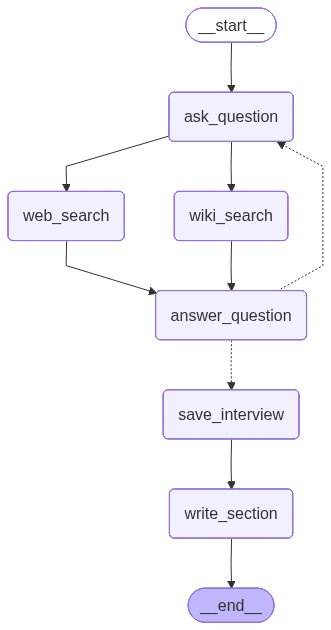

In [36]:
subbuilder = StateGraph(State)
subbuilder.add_node('ask_question',create_question)
subbuilder.add_node('web_search',web_search)
subbuilder.add_node('wiki_search',wiki_search)
subbuilder.add_node('answer_question',answer_question)
subbuilder.add_node('save_interview',save_interview)
subbuilder.add_node('write_section',writer_section)

subbuilder.add_edge(START , 'ask_question')
subbuilder.add_edge('ask_question' , 'web_search')
subbuilder.add_edge('ask_question' , 'wiki_search')
subbuilder.add_edge('web_search' , 'answer_question')
subbuilder.add_edge('wiki_search' , 'answer_question')
subbuilder.add_conditional_edges('answer_question',route_messages,['ask_question' , 'save_interview'])
subbuilder.add_edge('save_interview' , 'write_section')
subbuilder.add_edge('write_section' , END)

memory = MemorySaver()

graph1 = subbuilder.compile(memory)

display(Image(graph1.get_graph(xray=1).draw_mermaid_png()))

In [46]:
analyst = graph.get_state(config).values.get('analysts')
print(analyst[0])

Analyst(
    name='Dr. Elizabeth Hartwell',
    affiliation='Institute for Technology and Learning',
    role='Educational Technologist',
    description='Dr. Hartwell focuses on the educational implications of technology use. She is concerned with how 
different devices influence learning outcomes and student engagement. Her motive is to optimize educational 
experiences through the appropriate use of technology.'
)

In [49]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "2"}}
interview = graph1.invoke({"analyst": analyst[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

## The Role of Notebooks in Tech-Driven Classrooms

### Summary

The integration of technology in education has been a topic of significant dialogue, with proponents arguing that devices like laptops and tablets enable innovative learning experiences and equip students with essential skills for a technology-driven economy. However, the debate continues over their effectiveness and appropriateness in the classroom setting. Balancing technology use with traditional learning methods is crucial, and notebooks can play a vital role in this balance [1].

Research suggests that using notebooks can enhance learning, focus, and memory. A study highlighted by a teacher on Facebook noted that when she replaced laptops with pencil and paper, her students' performance improved. This aligns with the idea that handwriting can reinforce learning and retention better than typing [2]. While laptops and tablets excel in areas like research, writing, projects, and teaching real-world skills, they may not always be the best tool for every learning task. For instance, notebooks are often more effective for note-taking, brainstorming, and activities that require deep focus and creativity [2].

The trend of increasing technology use in classrooms accelerated during the COVID-19 pandemic, which necessitated remote learning and prompted many school districts to provide devices for all students. As educational approaches continue to adapt, including the incorporation of generative artificial intelligence tools, stakeholders are grappling with how to balance technology use with traditional learning methods while addressing issues of safety and academic integrity [1].

Sources:
[1] https://www.ebsco.com/research-starters/education/tablets-and-laptops-schools-overview/
[2] https://www.facebook.com/ScienceNaturePage/posts/a-teacher-replaced-laptops-with-pencil-and-paper-and-her-students-improved/1576904783890385/

In [50]:
class ResearchGraphState(TypedDict):
  topic:str
  max_analyst : int
  human_analyst_feedback : str
  analysts : List[Analyst]
  sections : Annotated[List , operator.add]
  introduction : str
  content : str
  conclusion :str
  final_report : str

In [51]:
from langgraph.types import Send
def initiate_all_interviews(state):
  human_analyst_feedback = state.get('human_analyst_feedback')
  if human_analyst_feedback:
    return "create_analyst"
  topic = state["topic"]
  return [Send("conduct_interview", {"analyst": analyst,
                                      "messages":[HumanMessage(content=f"So you said you were writing an article on {topic}?")]})
          for analyst in state['analysts']]

In [52]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic:

{topic}

You have a team of analysts. Each analyst has done two things:

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task:

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos.
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:

1. Use markdown formatting.
2. Include no pre-amble for the report.
3. Use no sub-heading.
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from:

{context}"""

In [53]:
def write_report(state : ResearchGraphState):
  sections = state['sections']
  topic = state['topic']

  formatted_str = '\n\n'.join([f'{section}' for section in sections])

  system_message = report_writer_instructions.format(topic = topic , context = formatted_str)

  report = llm.invoke([SystemMessage(content = system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")])

  return {'content':report.content}

In [54]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting.

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header.

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [55]:
def write_conclusion(state : ResearchGraphState):
  sections = state['sections']
  topic = state['topic']

  fomatted_str = "\n\n".join([f"{section}" for section in sections])

  instructions = intro_conclusion_instructions.format(topic = topic , formatted_str_sections = fomatted_str)

  conclusion = llm.invoke([instructions]+[HumanMessage(content = f"Write the report conclusion")])

  return {"conclusion":conclusion.content}

In [56]:
def write_introduction(state : ResearchGraphState):
  sections = state['sections']
  topic = state['topic']

  formatted_str = "\n\n".join([f"{section}" for section in sections])

  instructions = intro_conclusion_instructions.format(topic = topic , formatted_str_sections = formatted_str)

  intro = llm.invoke([instructions]+[HumanMessage(content = f"Write the report introduction")])

  return {"introduction":intro.content}

In [64]:
def finalize_report(state : ResearchGraphState):
  content = state['content']
  sources = None
  if content.startswith('##Insights'):
    content = content.strip('##Insights')

  if '##Sources' in content:
    try:
      content , sources = content.split("\n## Sources \n")
    except:
      sources = None

  final_report = state['introduction'] + "\n\n---\n\n"+content + "\n\n" + state["conclusion"]

  if sources is not None:
    final_report += "\n\n##Sources\n"+sources

  return {"final_report":final_report}


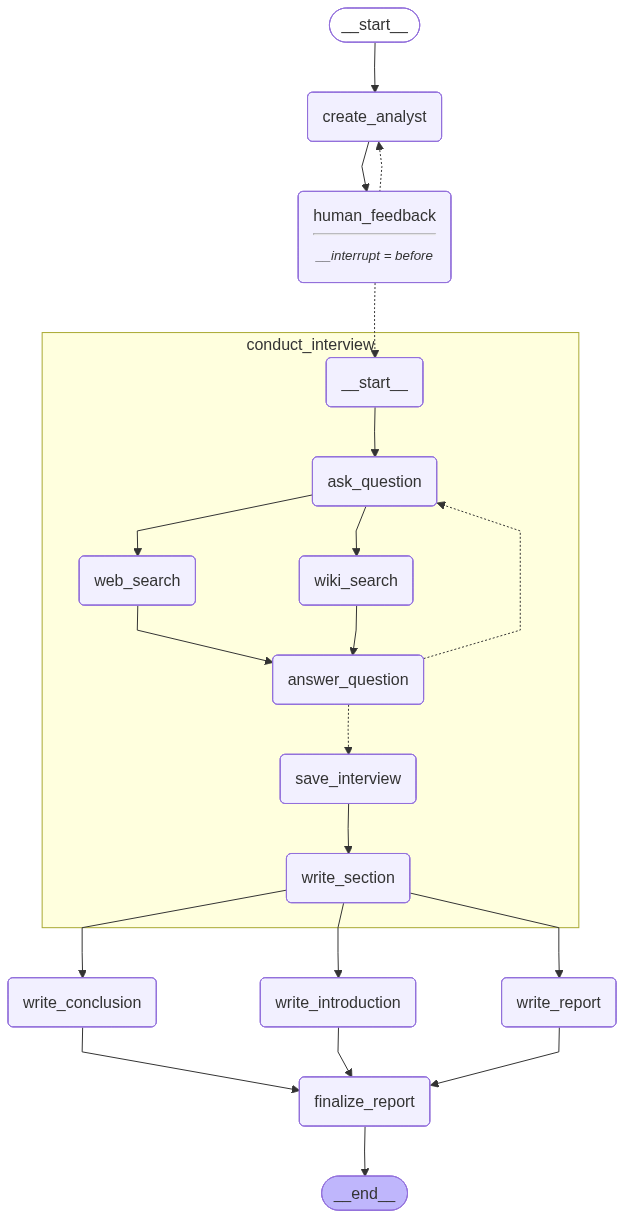

In [65]:
builder = StateGraph(ResearchGraphState)
builder.add_node('create_analyst',analyst_creator)
builder.add_node('human_feedback',human_feedback_node)
builder.add_node('conduct_interview',graph1)
builder.add_node('write_introduction',write_introduction)
builder.add_node('write_conclusion',write_conclusion)
builder.add_node('write_report',write_report)
builder.add_node('finalize_report',finalize_report)

builder.add_edge(START,'create_analyst')
builder.add_edge('create_analyst','human_feedback')
builder.add_conditional_edges("human_feedback",initiate_all_interviews , [
    "create_analyst" , "conduct_interview"
])
builder.add_edge('conduct_interview','write_introduction')
builder.add_edge('conduct_interview','write_conclusion')
builder.add_edge('conduct_interview','write_report')
builder.add_edge('write_report','finalize_report')
builder.add_edge(['write_conclusion','write_report','write_introduction'],'finalize_report')
builder.add_edge('finalize_report',END)

memory = MemorySaver()

graph = builder.compile(interrupt_before=['human_feedback'],checkpointer = memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [66]:
max_analyst = 3
topic = "Newtons Law"
thread = {"configurable":{"thread_id" : "11"}}

for event in graph.stream({"topic":topic,"max_analyst":max_analyst},thread , stream_mode="values"):
  analysts = event.get('analysts')
  if analysts:
    for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)


Name: Dr. Isaac Newton Scholar

Affiliation: Cambridge University

Role: Historical Physics Analyst

Description: Dr. Isaac Newton Scholar is an expert in the history of physics, specializing in the works of Sir 
Isaac Newton. Their focus is on the historical context and development of Newton's laws of motion and universal 
gravitation. They are concerned with accurately interpreting Newton's original works and understanding the impact 
of his discoveries on the scientific community. Their motive is to provide a deeper understanding of the historical
significance of Newton's laws and their enduring influence on modern physics.

--------------------------------------------------

...

Name: Dr. Gravitational Theories Researcher

Affiliation: California Institute of Technology

Role: Gravitational Theories Analyst

Description: Dr. Gravitational Theories Researcher is a theoretical physicist specializing in gravitational 
theories. Their focus is on the role of Newton's law of universal gravitation in modern theories of gravity, 
including general relativity. They are concerned with reconciling Newtonian gravity with contemporary understanding
of the universe. Their motive is to explore the boundaries and limitations of Newton's laws in the context of 
modern astrophysics and cosmology.

--------------------------------------------------

In [67]:
graph.update_state(thread , {"human_analyst_feedback":
                             "Add in the Professor of IIT BOMBAY AND MIT USA"},as_node = "human_feedback")

{'configurable': {'thread_id': '11',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17f9e2-c592-6331-8002-5743094154cc'}}

In [68]:
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Isaac Newton Scholar

Affiliation: Cambridge University

Role: Historical Physics Analyst

Description: Dr. Isaac Newton Scholar is an expert in the history of physics, specializing in the works of Sir 
Isaac Newton. Their focus is on the historical context and development of Newton's laws of motion and universal 
gravitation. They are concerned with accurately interpreting Newton's original works and understanding the impact 
of his discoveries on the scientific community. Their motive is to provide a deeper understanding of the historical
significance of Newton's laws and their enduring influence on modern physics.

--------------------------------------------------

...

Name: Dr. Rajiv Mehta

Affiliation: Indian Institute of Technology (IIT)

Role: Mechanical Engineer

Description: Dr. Mehta explores the role of Newton's laws in mechanical engineering, particularly in the design of 
machinery and mechanical systems. He is passionate about educating the next generation of engineers on the 
foundational principles of mechanics and their real-world applications.

--------------------------------------------------

In [69]:
graph.update_state(thread, {"human_analyst_feedback":
                            None}, as_node="human_feedback")

{'configurable': {'thread_id': '11',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17f9e2-da38-6420-8004-70b9d6fe463f'}}

In [70]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--

conduct_interview

--Node--

conduct_interview

--Node--

...

write_introduction

--Node--

write_report

--Node--

finalize_report

In [71]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# The Timeless Power and Boundaries of Newton's Laws

## Introduction

Newton’s laws of motion revolutionized physics, providing a rigorous framework for understanding forces and motion that remains foundational in aerospace and mechanical engineering. This report explores their enduring legacy—from guiding spacecraft trajectories to enabling mechanical systems—while examining their limitations in quantum mechanics. We delve into the first law’s role in aerospace, where inertia dictates flight stability and orbital maneuvers, and its applications in mechanical engineering, from rocket propulsion to structural design. However, quantum phenomena, like electron behavior and the double-slit experiment, reveal where Newtonian mechanics falter. By balancing historical context with modern challenges, this report underscores the laws’ brilliance and their boundaries in the quantum realm.

---

## Insights

Newton's laws of motion, as presented in *Philosophiæ Naturalis Principia Mathematica*, have profoundly influenced our understanding of the physical world, serving as a foundational framework for the relationship between forces and the motion of objects. These laws have been instrumental in the development of the concept of energy, a cornerstone of modern physics, and have set a standard for empirical investigation that continues to guide scientific inquiry [1][2][3][4].

However, Newton's laws have limitations, particularly when applied to quantum physics. At very small scales or high speeds, quantum mechanics introduces probabilistic elements and wave-particle duality, which are not accounted for in Newtonian mechanics. For instance, Newton's laws do not apply to particles at the quantum level, where phenomena like the uncertainty principle and quantum tunneling come into play. This is evident in the behavior of electrons in an atom, which, according to Newtonian mechanics, should spiral into the nucleus but are instead explained by quantum mechanics through quantized energy levels. The double-slit experiment further illustrates this limitation, as the interference pattern created by particles like electrons cannot be explained by Newton's deterministic paths but is described by quantum mechanics' probabilistic framework [1][2][3][4].

Newton's first law, the law of inertia, is particularly significant in aerospace engineering. It explains why objects remain at rest or in uniform motion unless acted upon by an external force. This principle is crucial for understanding and predicting the behavior of aircraft and spacecraft. In aerospace, it is applied during the cruising phase of an aircraft, where a balance of forces results in constant velocity, and in spacecraft design, where it aids in maneuvers like aerobraking. The law also plays a role in structural analysis and robotics, ensuring the stability and safety of aerospace vehicles [1][2][3].

In mechanical engineering, Newton's laws are the bedrock upon which the design and functionality of mechanical systems are built. The first law explains the behavior of objects in various mechanical systems, the second law (F = ma) is fundamental in calculating forces, and the third law, the law of action and reaction, is vital in propulsion systems. These principles have been applied historically and continue to be essential in modern engineering, from the construction of ancient structures to the development of contemporary vehicles and medical devices [1][2][3][4].

## Sources

[1] https://www.researchgate.net/publication/395710919_Newton's_First_Law_of_Motion_Inertia_and_Applications_in_Mechanics
[2] https://www.grc.nasa.gov/www/k-12/BGP/newton1.html
[3] https://en.wikipedia.org/wiki/Glossary_of_aerospace_engineering
[4] https://www.teachengineering.org/populartopics/view/newtonslaws/
[5] https://www.jove.com/science-education/v/14217/newton-s-law-of-motion
[6] https://engineeringlibrary.org/reference/application-of-newtons-laws-doe-handbook
[7] https://en.wikipedia.org/wiki/History_of_mechanical_engineering
[8] https://ui.adsabs.harvard.edu/abs/2026IJMMD..22...42W/abstract
[9] https://www.britannica.com/science/Newtons-laws-of-motion
[10] https://en.wikipedia.org/wiki/Newton%27s_laws_of_motion
[11] https://en.wikipedia.org/wiki/Energy

## Conclusion

Newton's laws of motion remain a cornerstone of physics, engineering, and technology, shaping our understanding of motion, force, and energy. From aerospace engineering, where inertia governs flight dynamics, to mechanical systems relying on action-reaction principles, these laws provide a robust framework for design and innovation. However, their limitations in quantum mechanics and relativistic scenarios highlight the evolving nature of scientific theory. By studying Newton’s work alongside modern physics, engineers and physicists gain deeper insights into both classical and cutting-edge applications. The enduring legacy of Newton’s laws lies in their foundational role, bridging historical discovery with contemporary advancements.